In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("data.csv")

In [8]:
df


,Age,Income,Salary,Rating,Annual_Income,Customer_Support_Calls,House_Price,Square_Feet,Temperature,City,Product_Type,Location,Diagnosis,Cabin,Embarked,Gender,Target,Price_Target
0,40.0,9165.0,55361,2.9,NaN,NaN,495310.0,2091,15.1,Dhaka,Unknown,A,NaN,NaN,S,Male,0,280.32
1,33.0,5522.0,48717,NaN,52868.0,1.0,368695.0,1504,28.3,Chittagong,C,C,Type3,NaN,S,Female,1,314.83
2,42.0,50589.0,64787,3.1,79526.0,2.0,453606.0,2052,22.0,Sylhet,A,C,Type1,NaN,C,Female,0,252.43
3,53.0,61289.0,80106,3.6,107581.0,1.0,359753.0,2075,22.7,Rajshahi,C,B,Type2,NaN,S,Female,0,239.21
4,32.0,1604.0,31872,4.0,89654.0,1.0,228869.0,1248,NaN,Rajshahi,A,C,Type2,NaN,S,Female,0,179.51
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,31.0,16472.0,50253,3.2,82289.0,4.0,NaN,1832,17.0,Dhaka,A,C,Type1,NaN,C,Female,0,309.92
996,56.0,11596.0,41951,2.7,32733.0,2.0,NaN,1127,17.0,Sylhet,A,C,Type1,Cabin_D,S,Male,0,222.41
997,42.0,NaN,44369,2.6,50537.0,2.0,346644.0,1654,24.7,Rajshahi,C,B,Type2,NaN,S,Female,0,221.89
998,NaN,276.0,52691,3.9,143880.0,4.0,307904.0,1908,Unknown,Rajshahi,B,B,NaN,NaN,Q,Female,0,293.69


In [9]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
Age                       180
Income                    150
Salary                      0
Rating                     80
Annual_Income             120
Customer_Support_Calls     80
House_Price               100
Square_Feet                 0
Temperature                50
City                       50
Product_Type                0
Location                    0
Diagnosis                 220
Cabin                     680
Embarked                    2
Gender                      0
Target                      0
Price_Target                0
dtype: int64


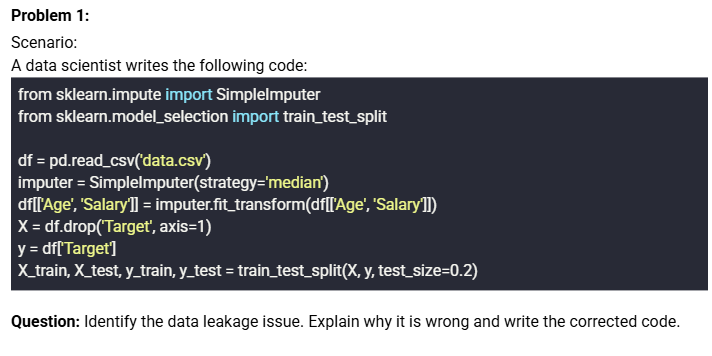

The mistake is that the imputer is applied before splitting the dataset into training and testing sets. This is called data leakage because the model gets information from the test data while calculating the median.
The correct way is to split the data first, then fit the imputer on the training data only, and use it to transform both the training and test data.

In [12]:
X = df.drop("Target", axis=1)
y = df["Target"]

# Split first
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Impute after splitting
imputer = SimpleImputer(strategy="median")

X_train[["Age", "Salary"]] = imputer.fit_transform(X_train[["Age", "Salary"]])
X_test[["Age", "Salary"]] = imputer.transform(X_test[["Age", "Salary"]])

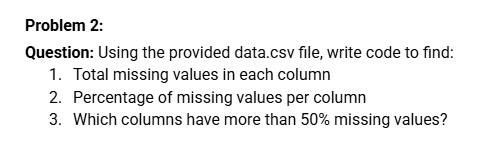

In [14]:
print(df.isnull().sum())

Age                       180
Income                    150
Salary                      0
Rating                     80
Annual_Income             120
Customer_Support_Calls     80
House_Price               100
Square_Feet                 0
Temperature                50
City                       50
Product_Type                0
Location                    0
Diagnosis                 220
Cabin                     680
Embarked                    2
Gender                      0
Target                      0
Price_Target                0
dtype: int64


In [13]:
missing_percent = (df.isnull().sum()/len(df))*100

print(missing_percent)

Age                       18.0
Income                    15.0
Salary                     0.0
Rating                     8.0
Annual_Income             12.0
Customer_Support_Calls     8.0
House_Price               10.0
Square_Feet                0.0
Temperature                5.0
City                       5.0
Product_Type               0.0
Location                   0.0
Diagnosis                 22.0
Cabin                     68.0
Embarked                   0.2
Gender                     0.0
Target                     0.0
Price_Target               0.0
dtype: float64


In [17]:
print(missing_percent[missing_percent>50])

Cabin    68.0
dtype: float64


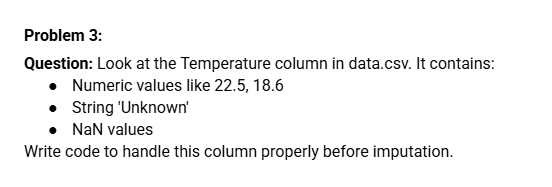

In [18]:
# Replace Unknown with NaN
df["Temperature"] = df["Temperature"].replace("Unknown", pd.NA)

# Convert to numeric
df["Temperature"] = pd.to_numeric(
    df["Temperature"],
    errors="coerce"
)

# Median imputation
imputer = SimpleImputer(strategy="median")

df["Temperature"] = imputer.fit_transform(
    df[["Temperature"]]
)

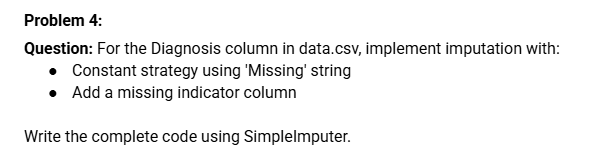

In [19]:
imputer = SimpleImputer(
    strategy="constant",
    fill_value="Missing",
    add_indicator=True
)

result = imputer.fit_transform(df[["Diagnosis"]])

df["Diagnosis"] = result[:,0]
df["Diagnosis_Missing"] = result[:,1].astype(int)

print(df[["Diagnosis","Diagnosis_Missing"]].head())

  Diagnosis  Diagnosis_Missing
0   Missing                  1
1     Type3                  0
2     Type1                  0
3     Type2                  0
4     Type2                  0


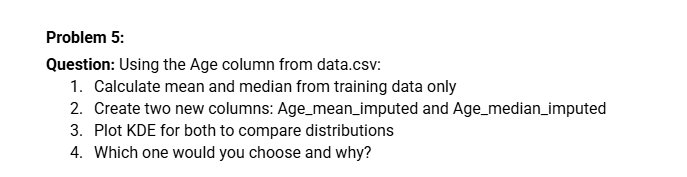

In [20]:
X = df.drop("Target", axis=1)
y = df["Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
age_mean = X_train["Age"].mean()

age_median = X_train["Age"].median()

print("Mean =", age_mean)
print("Median =", age_median)

Mean = 34.6338880484115
Median = 34.0


In [22]:
X_train["Age_mean_imputed"] = X_train["Age"].fillna(age_mean)

X_train["Age_median_imputed"] = X_train["Age"].fillna(age_median)

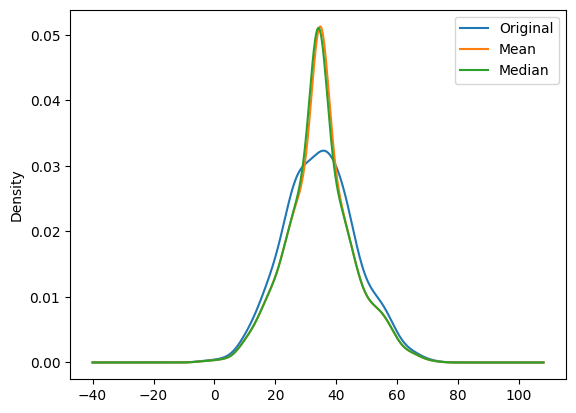

In [23]:
X_train["Age"].plot(kind="kde", label="Original")

X_train["Age_mean_imputed"].plot(kind="kde", label="Mean")

X_train["Age_median_imputed"].plot(kind="kde", label="Median")

plt.legend()
plt.show()

Median imputation is preferred because:

1.It is robust to outliers.

2.It preserves the distribution better when data is skewed.

3.Mean is affected by extreme values.

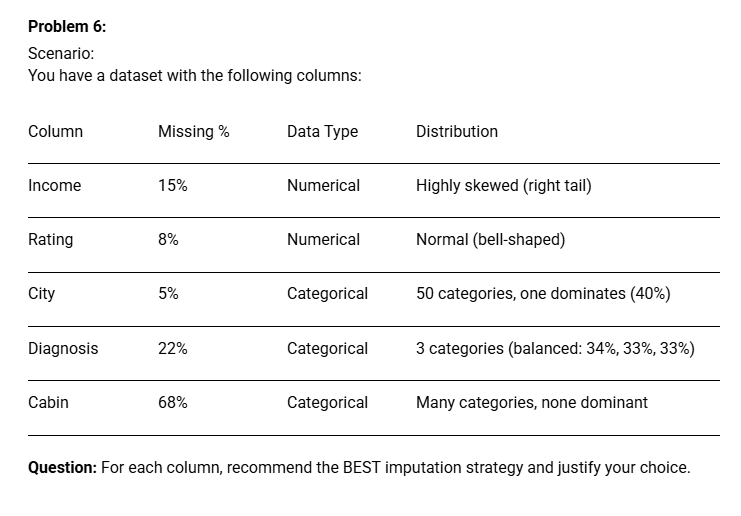

| Column    | Missing % | Best Strategy                       | Reason                                                   |
| --------- | --------- | ----------------------------------- | -------------------------------------------------------- |
| Income    | 15%       | Median                              | Highly skewed; median is robust to outliers.             |
| Rating    | 8%        | Mean                                | Approximately normal distribution.                       |
| City      | 5%        | Most Frequent                       | One category dominates (40%).                            |
| Diagnosis | 22%       | Constant ("Missing")                | Missingness may carry information.                       |
| Cabin     | 68%       | Drop column (or Constant "Unknown") | Too many missing values; imputation may not be reliable. |
